In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")
cfe.logger.setLevel("DEBUG")

[2025年04月24日 19时17分59秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
fadata = cfe.data.read_pancrease_cellrank(n_obs=500)
fadata

[2025年04月24日 19时18分00秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 500 × 5974
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'T_fwd_params', 'clusters_colors', 'clusters_fine_colors', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'cfe'
    obsm: 'T_fwd_umap', 'X_pca', 'X_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'spliced', 'unspliced', 'velocity', 'velo

                        DEBUG    plot_trajectory                                                                   
[2025年04月24日 19时18分01秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (208, 500), finished!                                      
[2025年04月24日 19时18分02秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 19时18分03秒] DEBUG    add waypoints shape is (208, 500), finished!                                


AnnData object with n_obs × n_vars = 500 × 5974
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'milestone_color', 'milestone'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'T_fwd_params', 'clusters_colors', 'clusters_fine_colors', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'cfe', 'milestone_color_dict', 'milestone_colors', 'milestone_color_colors'
    obsm: 'T_fwd_umap', 'X_pca', 'X_umap'
    varm: 'PCs', 'l

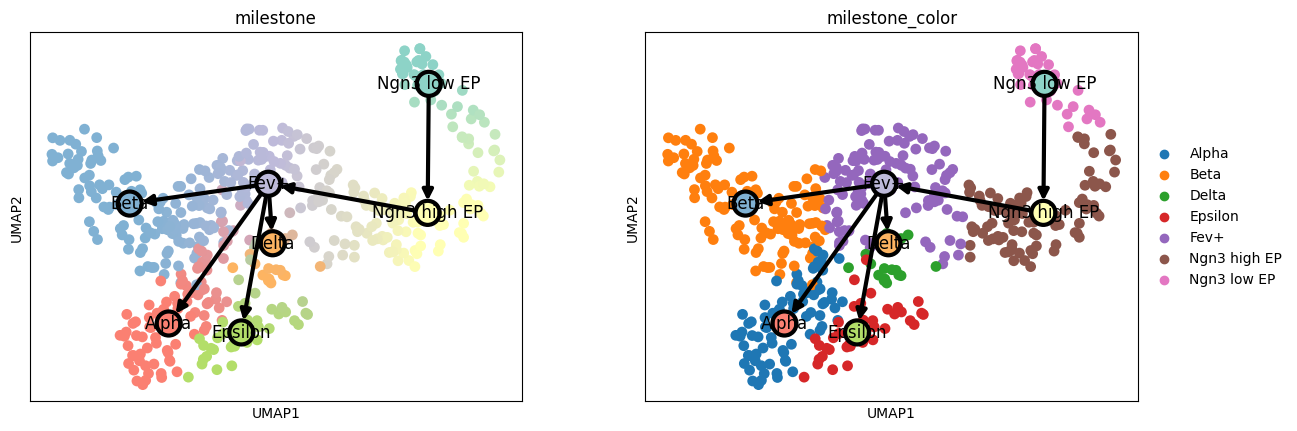

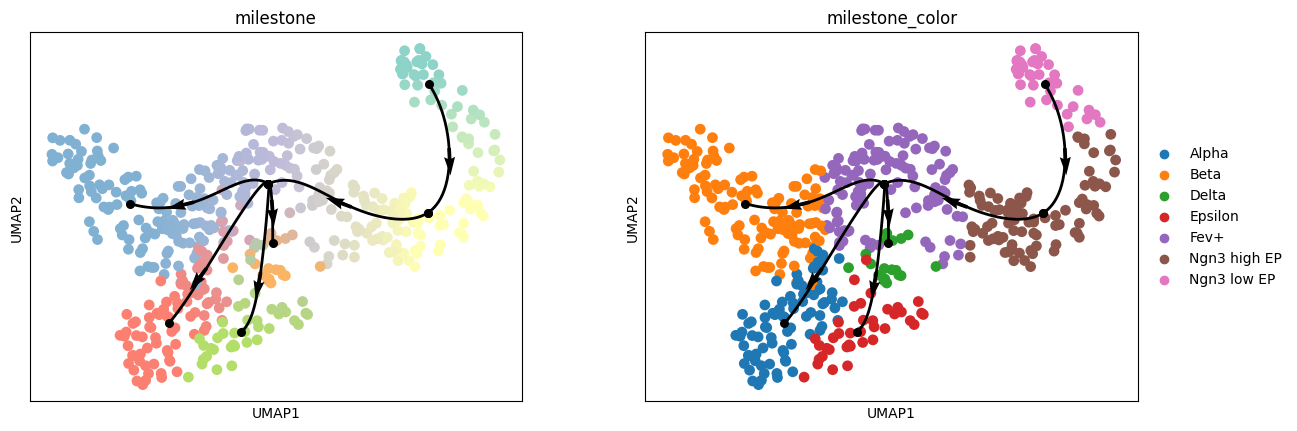

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月24日 19时18分05秒] INFO     find wrapper type: directed                                                 


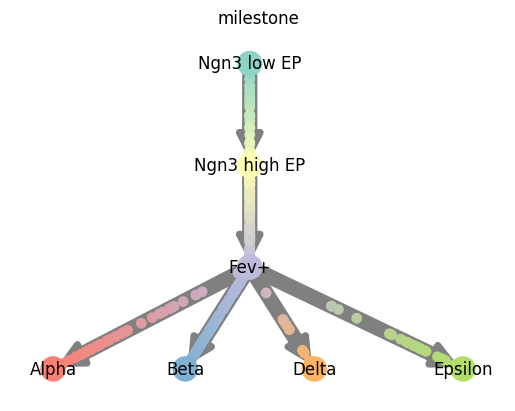

In [4]:
cfe.plot.plot_wrapper(fadata)

[2025年04月24日 19时18分08秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cellrank at 0x73a431fc9870> from                    
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cellrank.py                                                                       
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73a4e0326800>                                                                   
Defaulting to `'gmres'` solver.


  0%|          | 0/4 [00:00<?, ?/s]

probability wrapper
[2025年04月24日 19时18分12秒] DEBUG    Add trajectory by wrapper type: probability                                 
                        DEBUG    Wrapper type: probability                                                         
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   
[2025年04月24日 19时18分13秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 19时18分14秒] DEBUG    add waypoints shape is (204, 500), finished!                                


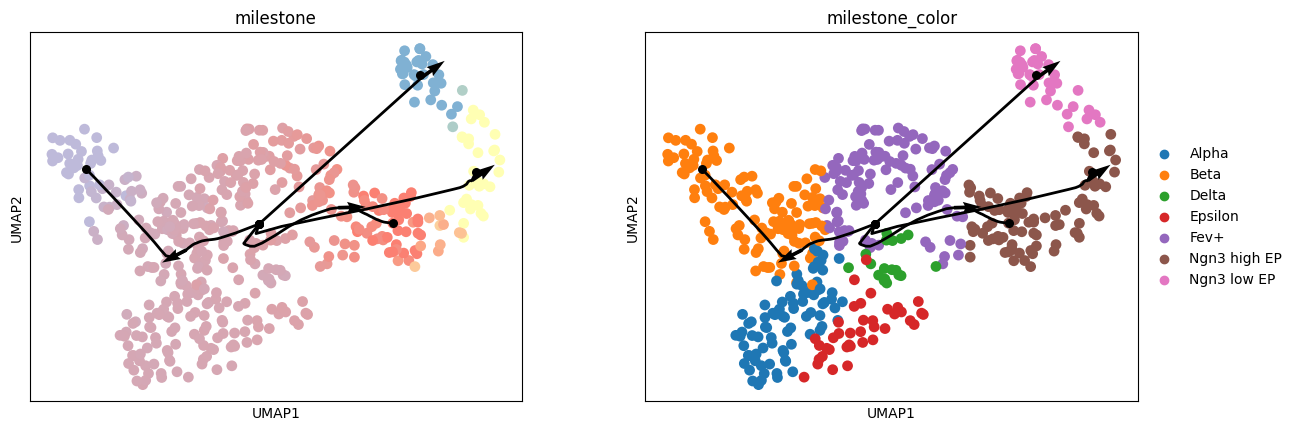

In [5]:
prior_information = {}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {
    "n_states": 11,
    "n_terminal_states": 4,
    "wrapper_type": "probability",
    # "terminal_states": ["Alpha", "Beta", "Epsilon", "Delta"],
}  # add parameters when inferring trajectory


method_name_list = ["cellrank"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [6]:
parameters["wrapper_type"] = "probability"
parameters["terminal_states"] = ["Alpha", "Beta", "Epsilon", "Delta"]

method_name_list = ["cellrank"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年04月24日 19时18分15秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cellrank at 0x73a42b9cbbe0> from                    
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cellrank.py                                                                       
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73a42bf0aef0>                                                                   


KeyError: "Invalid lineage name `'Beta'`. Valid names are: `['Beta_1', 'Beta_2', 'Epsilon_1', 'Epsilon_2', 'Alpha', 'Ngn3 high EP_1', 'Ngn3 low EP', 'Beta_3', 'Beta_4', 'Fev+', 'Ngn3 high EP_2']`."

In [ ]:
# 查看里程碑
trajectory_history_dict = fadata.uns["cfe"]["trajectory_history_dict"]
for k in trajectory_history_dict.keys():
    if "cellrank" in k:
        print(trajectory_history_dict[k]["milestone_wrapper"]["id_list"])

['milestone_begin', 'Alpha', 'Beta_2', 'Ngn3 high EP_2', 'Ngn3 low EP']
['milestone_begin', 'Beta', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP']
['milestone_begin', 'Alpha', 'Beta_2', 'Ngn3 high EP_2', 'Ngn3 low EP']
